# **NLP Project : Youtube Comments Classification** 🔡👨🏻‍💻📝

## 1️⃣ Required Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

import spacy
import re
nlp = spacy.load("en_core_web_sm")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_auc_score, f1_score
import time
import joblib

## 2️⃣ Read Dataset

In [2]:
path_train = 'https://drive.google.com/uc?export=download&id=1I1gaja_vShcNNp4ZoXhbyZVCPHoIvBDs'
df_train = pd.read_csv(path_train)

In [3]:
df_train.shape

(159571, 8)

In [4]:
df_train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
path_test = 'https://drive.google.com/uc?export=download&id=1vPQyHItI-uHV1H5pMMEe8jgM5SjiUMLj'
df_test = pd.read_csv(path_test)

In [6]:
df_test.shape

(153164, 2)

In [7]:
df_test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


## 3️⃣ Exploratory Data Analysis (EDA)

### Information

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


### Check Columns

In [9]:
df_train.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [10]:
df_train.drop(columns=['id'], axis=1, inplace=True)

In [11]:
df_test.drop(columns=['id'], axis=1, inplace=True)

### Missing Values

In [12]:
df_train.isna().sum()

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

### Duplication Values

In [13]:
df_train.duplicated().sum()

0

### Number of normal and unnormal comments

In [14]:
cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
count = (df_train[cols] == 0).all(axis=1).sum()
print(count)

143346


### Percentage Each Label

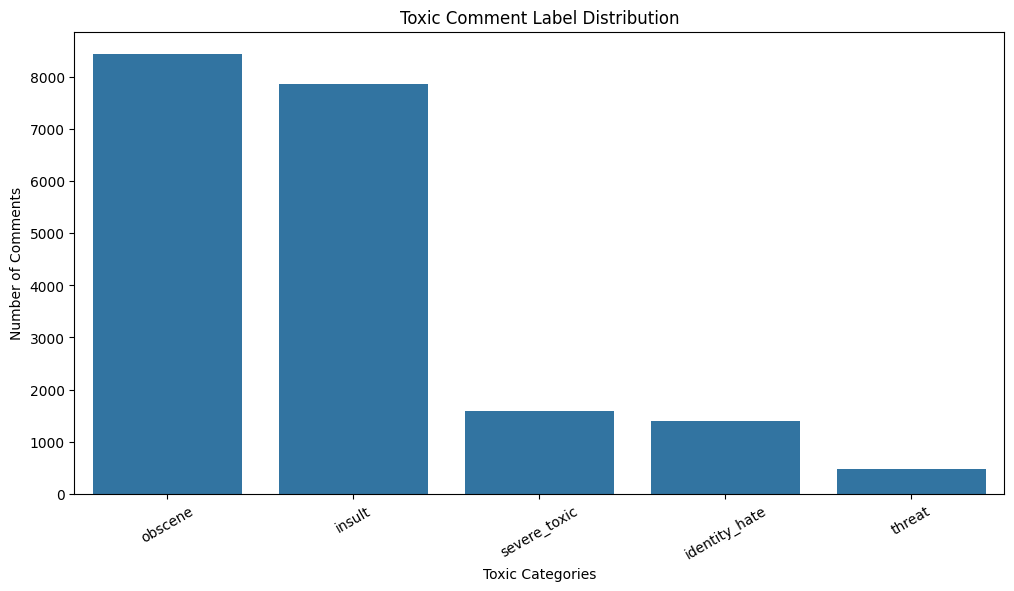

In [15]:
labels = df_train.columns[2:]
counts = df_train[labels].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=counts.index, y=counts.values)

plt.title("Toxic Comment Label Distribution")
plt.ylabel("Number of Comments")
plt.xlabel("Toxic Categories")

plt.xticks(rotation=30)
plt.show()

### Comment length Histogram

In [16]:
df_train["comment_length"] = df_train["comment_text"].str.len()

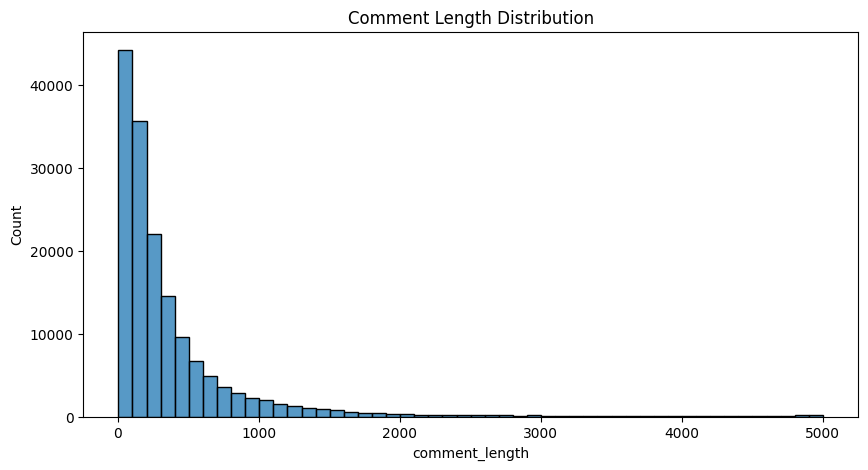

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df_train["comment_length"], bins=50)
plt.title("Comment Length Distribution")
plt.show()

### Boxplot: Comment Length vs Toxicity

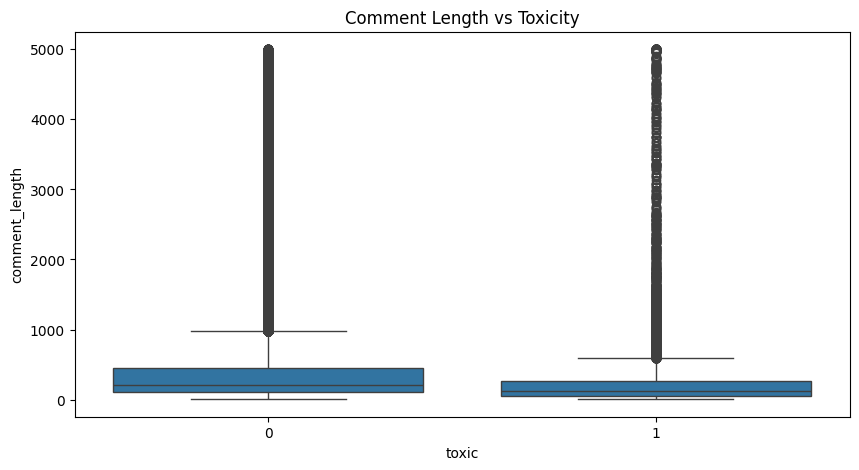

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_train["toxic"], y=df_train["comment_length"])
plt.title("Comment Length vs Toxicity")
plt.show()

### Function : Analysis Text

In [19]:
def analyze_text(text):
    # 1. Show Original Text
    print('\n-- 🔹 1. Original Text --')
    print('Text:', text)
    print('-' * 20)

    # 2. Basic Cleaning
    print('-- 🔹 2. Cleaned Text (Preprocessing) --')
    text_cleaned = re.sub(r"https?://\S+|www\.\S+", "", text) # Remove URLs
    text_cleaned = re.sub(r"[^a-zA-Z\s]", "", text_cleaned) # Remove symbols and numbers (Optional)
    print('Cleaned:', text_cleaned)
    print('-' * 20)

    # Process text with SpaCy once for all subsequent steps
    doc = nlp(text_cleaned.lower())

    # 3. Tokenization & Lemmatization
    # Lemma is better than Stemming as it returns the correct linguistic root
    print('-- 🔹 3. Tokens & Lemmas --')
    tokens = []
    lemmas = []
    for token in doc:
        tokens.append(token.text)
        lemmas.append(token.lemma_)

    print('Tokens:', tokens)
    print('Lemmas (Roots):', lemmas)
    print('-' * 20)

    # 4. StopWords & Final Filtering
    # Extracting the clean sentence for the Machine Learning model
    print('-- 🔹 4. Filtered Text (No Stopwords) --')
    filtered_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    final_text = " ".join(filtered_tokens)

    print('Filtered Tokens:', filtered_tokens)
    print('Final Ready Text:', final_text)
    print('-' * 20)

    # 5. POS Tagging (Part of Speech)
    # Performed on the full context (doc) for better accuracy
    print('-- 🔹 5. POS Analysis (Meaning) --')
    for token in list(doc):
        print(f"Word: {token.text:10} | Tag: {token.pos_:6} | Explain: {spacy.explain(token.pos_)}")
    print('-' * 20)

    return final_text

In [20]:
# Testing the function
my_comment = df_train.comment_text[0]
final_output = analyze_text(my_comment)


-- 🔹 1. Original Text --
Text: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
--------------------
-- 🔹 2. Cleaned Text (Preprocessing) --
Cleaned: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted They werent vandalisms just closure on some GAs after I voted at New York Dolls FAC And please dont remove the template from the talk page since Im retired now
--------------------
-- 🔹 3. Tokens & Lemmas --
Tokens: ['explanation', '\n', 'why', 'the', 'edits', 'made', 'under', 'my', 'username', 'hardcore', 'metallica', 'fan', 'were', 'reverted', 'they', 'were', 'nt', 'vandalisms', 'just', 'closure', 'on', 'some', 'gas', 'after', 'i', 'voted', 'at', 'new', 'york', 'dolls', 'fac', 'and', 'please', 'do', 'nt', 'remove', 'the', 'template', 'from

### Correlation Matrix

In [21]:
# Define your target columns
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [22]:
def plot_correlation(df):
    plt.figure(figsize=(10, 8))
    # Calculate Pearson correlation between labels
    correlation = df[target_cols].corr()
    sns.heatmap(correlation, annot=True, cmap='Reds', fmt=".2f", linewidths=.5)
    plt.title('Correlation Between Toxic Labels', fontsize=15)
    plt.show()

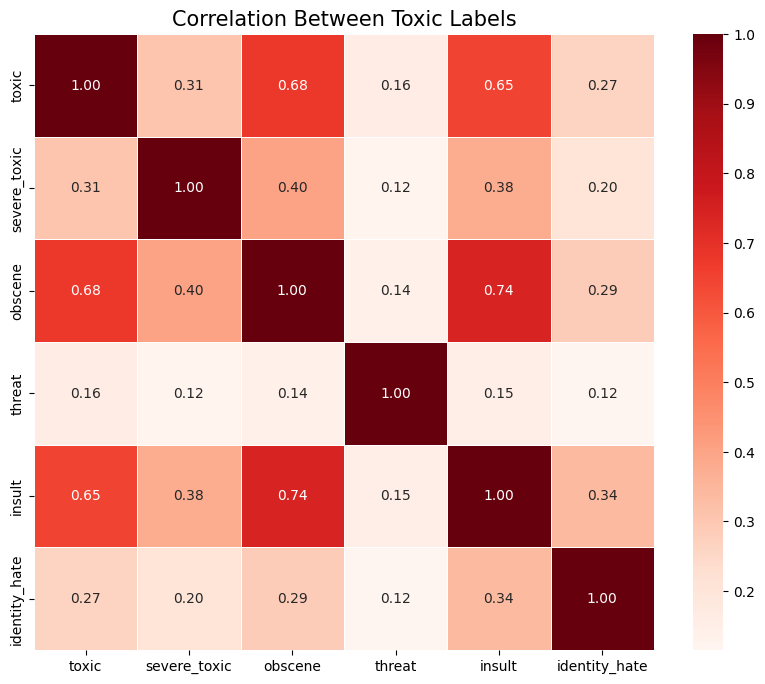

In [23]:
plot_correlation(df_train)

### Ngrams Plot

In [24]:
def plot_top_ngrams(df, label, n=2, top_k=20):
    specific_df = df[df[label] == 1]

    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(specific_df['cleaned_text'].astype(str))
    bag_of_words = vec.transform(specific_df['cleaned_text'].astype(str))

    # Sum frequencies
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    ngram_df = pd.DataFrame(words_freq[:top_k], columns=['N-gram', 'Frequency'])

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Frequency', y='N-gram', data=ngram_df, palette='viridis')
    plt.title(f'Top {top_k} Bigrams for Label: {label.upper()}', fontsize=15)
    plt.show()

Generating Top Bigrams for 'Identity Hate'...


C:\Users\moham\AppData\Local\Temp\ipykernel_25516\1311086949.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=ngram_df, palette='viridis')


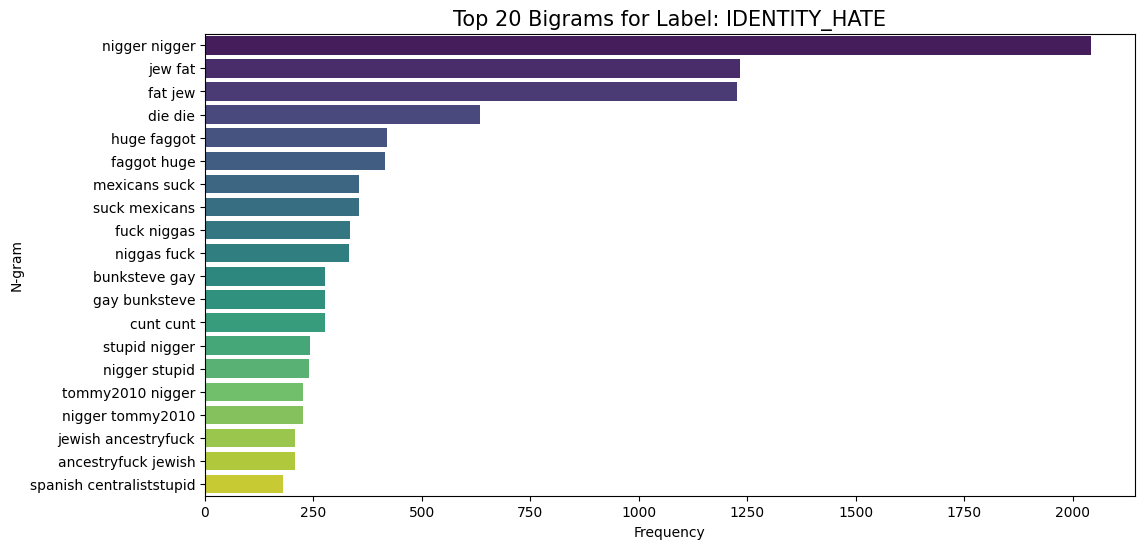

In [28]:
print("Generating Top Bigrams for 'Identity Hate'...")
# You can change 'identity_hate' to any other label like 'threat' or 'toxic'
plot_top_ngrams(df_train, label='identity_hate', n=2)

## 4️⃣ Data Preprocessing

### Remove not impotant things

In [26]:
def fast_process_dataset(df, column_name):
    with nlp.select_pipes(disable=["parser", "ner"]):

        texts = df[column_name].astype(str).tolist()
        cleaned_docs = []

        for doc in nlp.pipe(texts, batch_size=1000, n_process=2):

            text = doc.text.lower()
            text = re.sub(r"https?://\S+|www\.\S+", "", text)
            text = re.sub(r"[^a-zA-Z\s]", "", text)

            filtered_text = " ".join([token.lemma_ for token in doc
                                     if not token.is_stop and not token.is_punct])
            cleaned_docs.append(filtered_text)

    return cleaned_docs

print("Starting Cleaning... This will be much faster now!")
df_train['cleaned_text'] = fast_process_dataset(df_train, 'comment_text')
df_test['cleaned_text'] = fast_process_dataset(df_test, 'comment_text')

Starting Cleaning... This will be much faster now!


### Save output to not clean second time

In [27]:
df_train.to_csv('cleaned_train_data.csv', index=False)
df_test.to_csv('cleaned_test_data.csv', index=False)

## 5️⃣ Split Data into Train and Test Sets

In [31]:
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
y = df_train[target_cols]
X = df_train['cleaned_text']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((127656,), (31915,), (127656, 6), (31915, 6))

In [34]:
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 6️⃣ Modeling

### Baseline 

In [36]:
models = {
    'Weighted Logistic Regression': LogisticRegression(solver='liblinear', class_weight='balanced'),
    'Naive Bayes (Baseline)': MultinomialNB(), # NB doesn't support class_weight='balanced'
    'Weighted Linear SVM': LinearSVC(dual=False, class_weight='balanced')
}

results = {}
best_f1 = -1
best_model_name = None
best_clf = None

print("--- 📊 Starting Weighted Model Comparison ---")

for name, model in models.items():
    start_time = time.time()

    # Wrap in MultiOutput for 6 labels
    clf = MultiOutputClassifier(model)
    clf.fit(X_train_tfidf, y_train)

    # A. Get Probabilities/Scores for AUC-ROC
    if 'SVM' in name:
        y_score = np.transpose([est.decision_function(X_test_tfidf) for est in clf.estimators_])
    else:
        y_score = np.transpose([est.predict_proba(X_test_tfidf)[:, 1] for est in clf.estimators_])

    # B. Get Hard Predictions for F1-Score
    y_pred = clf.predict(X_test_tfidf)

    # C. Calculate Metrics
    auc_score = roc_auc_score(y_test, y_score)
    
    # Using 'weighted' F1 to account for label imbalance
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    end_time = time.time()
    duration = end_time - start_time

    results[name] = {
        'AUC-ROC': auc_score,
        'F1-Weighted': f1_weighted,
        'Time': duration
    }

    print(f"✅ {name} Finished")
    print(f"   Score -> AUC-ROC: {auc_score:.4f} | F1-Weighted: {f1_weighted:.4f} | Time: {duration:.2f}s")

    # We now pick the best model based on F1-Score (more reliable for imbalance)
    if f1_weighted > best_f1:
        best_f1 = f1_weighted
        best_model_name = name
        best_clf = clf

print("\n--- 🏆 Final Comparison (Sorted by F1-Score) ---")
for name, data in results.items():
    print(f"{name}: F1 = {data['F1-Weighted']:.4f}, AUC = {data['AUC-ROC']:.4f}, Time = {data['Time']:.2f}s")

print(f"\n⭐ Recommended Model: {best_model_name} with Weighted F1: {best_f1:.4f}")

--- 📊 Starting Weighted Model Comparison ---
✅ Weighted Logistic Regression Finished
   Score -> AUC-ROC: 0.9760 | F1-Weighted: 0.6736 | Time: 5.37s
✅ Naive Bayes (Baseline) Finished
   Score -> AUC-ROC: 0.9443 | F1-Weighted: 0.5719 | Time: 0.19s
✅ Weighted Linear SVM Finished
   Score -> AUC-ROC: 0.9608 | F1-Weighted: 0.6548 | Time: 11.58s

--- 🏆 Final Comparison (Sorted by F1-Score) ---
Weighted Logistic Regression: F1 = 0.6736, AUC = 0.9760, Time = 5.37s
Naive Bayes (Baseline): F1 = 0.5719, AUC = 0.9443, Time = 0.19s
Weighted Linear SVM: F1 = 0.6548, AUC = 0.9608, Time = 11.58s

⭐ Recommended Model: Weighted Logistic Regression with Weighted F1: 0.6736


## 7️⃣ Save Models

In [37]:
joblib.dump(best_clf, 'toxic_weighted_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Models saved successfully! 🎉")

Models saved successfully! 🎉


## **Thank You** 🎀🫶🏻💌💓